# Notebook 2: Relationships Between Type, Task, and Goal

This notebook examines how the three final labels relate to each other:

- `final_type`
- `final_task`
- `final_goal`

It reflects a **behavioral structure**:
- the **kind of information** the user wants,
- the **task** they are trying to do with that information,
- and the **goal** they ultimately care about.

This notebook helps answer questions such as:

1. Do certain information types consistently support certain tasks?
2. Do certain tasks tend to serve certain goals?
3. Are there common behavioral pipelines, such as `recommendation → decision-making → purchase`?


In [66]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/bin/python
3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

In [68]:
file_path = '../processed_data/Reconciled_Final.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (2115, 6)


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## Type × Task relationship

This section examines whether certain kinds of information are associated with certain tasks.

In [69]:
type_task_counts = pd.crosstab(rel_df['final_type'], rel_df['final_task'])
type_task_counts

final_task,barrier management,evaluation,learn,logistics,na,option seeking,perform
final_type,,,,,,,
comparative,0,26,0,0,0,0,0
experiential,4,26,43,0,0,1,2
factual,0,3,223,27,12,8,0
how-to (procedural),32,0,72,0,0,23,2
how-to (psychological),43,0,2,0,0,2,0
ideas/options,11,4,63,12,0,798,6
mechanism,0,0,34,0,0,0,0
na,0,0,1,1,211,0,0
normative,0,75,25,1,0,0,0


In [70]:
type_task_rowpct = pd.crosstab(rel_df['final_type'], rel_df['final_task'], normalize='index')
type_task_rowpct.round(3)

final_task,barrier management,evaluation,learn,logistics,na,option seeking,perform
final_type,,,,,,,
comparative,0.000,1.000,0.000,0.000,0.000,0.000,0.000
experiential,0.053,0.342,0.566,0.000,0.000,0.013,0.026
factual,0.000,0.011,0.817,0.099,0.044,0.029,0.000
how-to (procedural),0.248,0.000,0.558,0.000,0.000,0.178,0.016
how-to (psychological),0.915,0.000,0.043,0.000,0.000,0.043,0.000
ideas/options,0.012,0.004,0.070,0.013,0.000,0.893,0.007
mechanism,0.000,0.000,1.000,0.000,0.000,0.000,0.000
na,0.000,0.000,0.005,0.005,0.991,0.000,0.000
normative,0.000,0.743,0.248,0.010,0.000,0.000,0.000


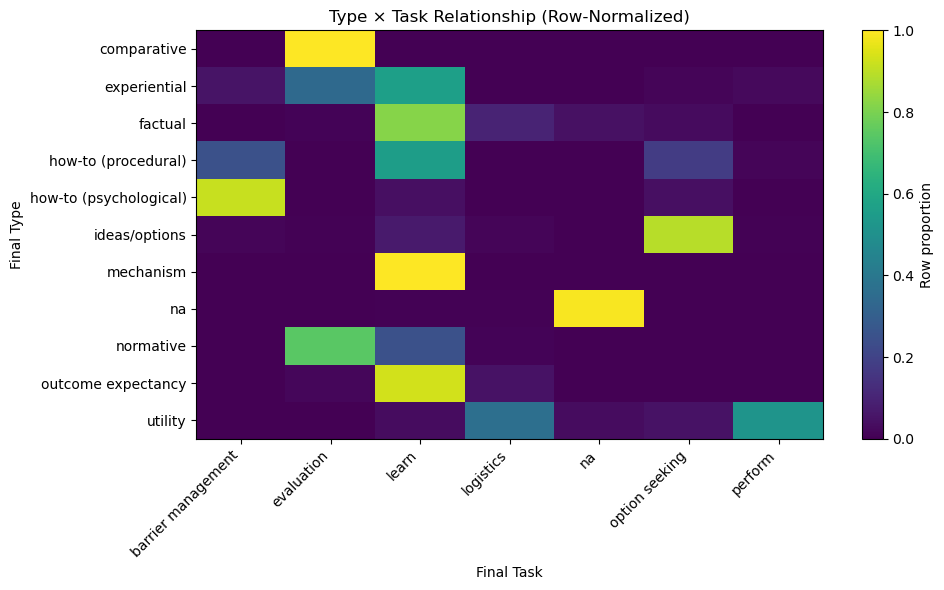

In [71]:
plt.figure(figsize=(10, 6))
plt.imshow(type_task_rowpct, aspect='auto')
plt.xticks(range(len(type_task_rowpct.columns)), type_task_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_task_rowpct.index)), type_task_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Task Relationship (Row-Normalized)')
plt.xlabel('Final Task')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

##  Task × Goal relationship

In [72]:
task_goal_counts = pd.crosstab(rel_df['final_task'], rel_df['final_goal'])
task_goal_counts

final_goal,action,decision making,motivational reasoning,na,plan
final_task,,,,,
barrier management,3,0,45,0,42
evaluation,0,92,33,0,14
learn,20,75,157,0,457
logistics,33,9,1,1,32
na,10,2,0,203,10
option seeking,15,92,7,0,721
perform,37,1,0,1,2


In [73]:
task_goal_rowpct = pd.crosstab(rel_df['final_task'], rel_df['final_goal'], normalize='index')
task_goal_rowpct.round(3)

final_goal,action,decision making,motivational reasoning,na,plan
final_task,,,,,
barrier management,0.033,0.000,0.500,0.000,0.467
evaluation,0.000,0.662,0.237,0.000,0.101
learn,0.028,0.106,0.221,0.000,0.645
logistics,0.434,0.118,0.013,0.013,0.421
na,0.044,0.009,0.000,0.902,0.044
option seeking,0.018,0.110,0.008,0.000,0.863
perform,0.902,0.024,0.000,0.024,0.049


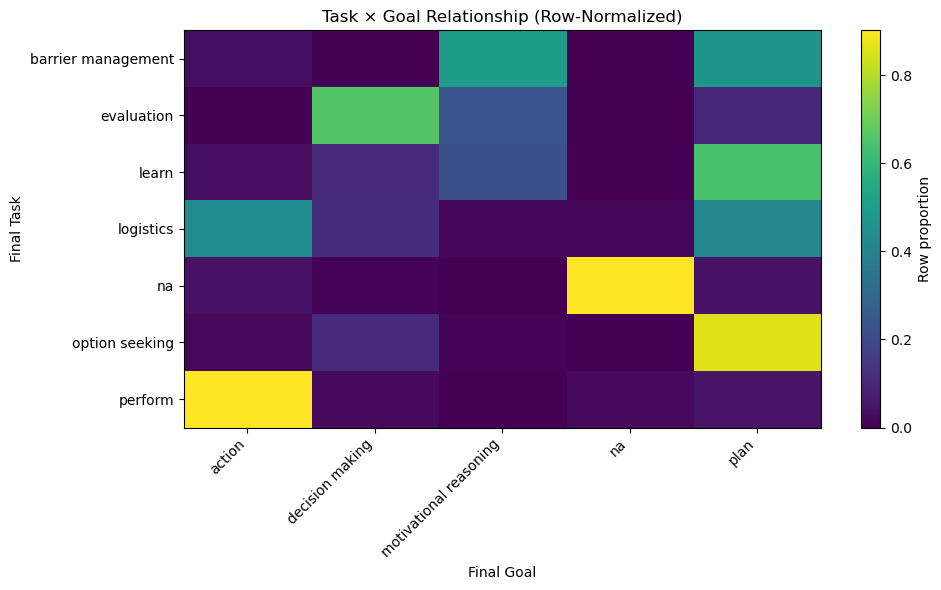

In [74]:
plt.figure(figsize=(10, 6))
plt.imshow(task_goal_rowpct, aspect='auto')
plt.xticks(range(len(task_goal_rowpct.columns)), task_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(task_goal_rowpct.index)), task_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Task × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Task')
plt.tight_layout()
plt.show()

## Type × Goal relationship

In [75]:
type_goal_counts = pd.crosstab(rel_df['final_type'], rel_df['final_goal'])
type_goal_counts

final_goal,action,decision making,motivational reasoning,na,plan
final_type,,,,,
comparative,0,24,0,0,2
experiential,0,7,34,0,35
factual,9,32,5,2,225
how-to (procedural),17,0,11,0,101
how-to (psychological),0,0,33,0,14
ideas/options,24,108,4,0,758
mechanism,2,6,15,0,11
na,8,0,0,202,3
normative,0,63,10,0,28


In [76]:
type_goal_rowpct = pd.crosstab(rel_df['final_type'], rel_df['final_goal'], normalize='index')
type_goal_rowpct.round(3)

final_goal,action,decision making,motivational reasoning,na,plan
final_type,,,,,
comparative,0.000,0.923,0.000,0.000,0.077
experiential,0.000,0.092,0.447,0.000,0.461
factual,0.033,0.117,0.018,0.007,0.824
how-to (procedural),0.132,0.000,0.085,0.000,0.783
how-to (psychological),0.000,0.000,0.702,0.000,0.298
ideas/options,0.027,0.121,0.004,0.000,0.848
mechanism,0.059,0.176,0.441,0.000,0.324
na,0.038,0.000,0.000,0.948,0.014
normative,0.000,0.624,0.099,0.000,0.277


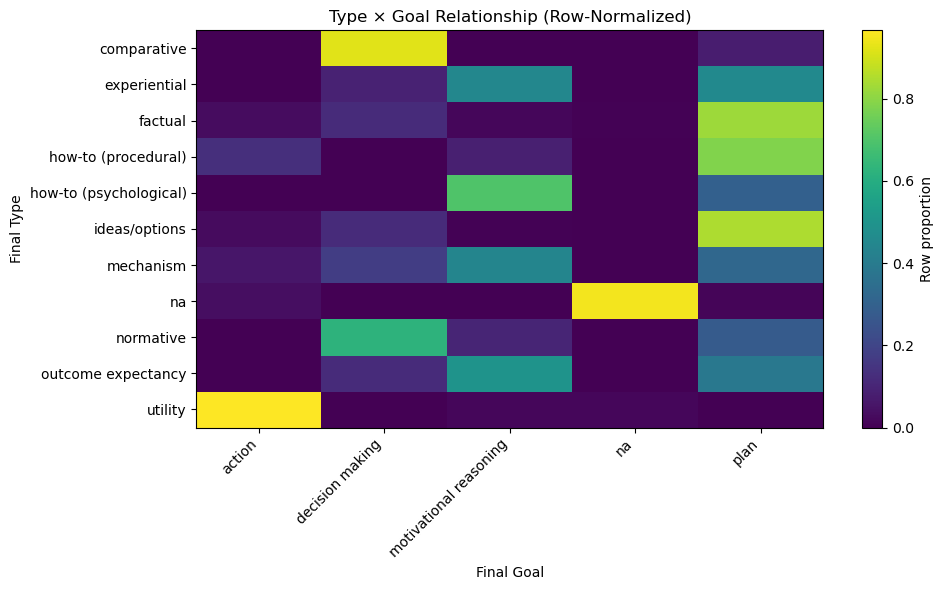

In [77]:
plt.figure(figsize=(10, 6))
plt.imshow(type_goal_rowpct, aspect='auto')
plt.xticks(range(len(type_goal_rowpct.columns)), type_goal_rowpct.columns, rotation=45, ha='right')
plt.yticks(range(len(type_goal_rowpct.index)), type_goal_rowpct.index)
plt.colorbar(label='Row proportion')
plt.title('Type × Goal Relationship (Row-Normalized)')
plt.xlabel('Final Goal')
plt.ylabel('Final Type')
plt.tight_layout()
plt.show()

## Full behavioral pipeline

Now we combine all three labels into a single pipeline. A query is often more interpretable as a **sequence** than as three separate labels.


In [78]:
rel_df['pipeline'] = (
    rel_df['final_type'].astype(str) + ' → ' +
    rel_df['final_task'].astype(str) + ' → ' +
    rel_df['final_goal'].astype(str)
)

pipeline_counts = rel_df['pipeline'].value_counts().reset_index()
pipeline_counts.columns = ['pipeline', 'count']
pipeline_counts['percent'] = pipeline_counts['count'] / len(rel_df) * 100
pipeline_counts.head(20)

,pipeline,count,percent
0,ideas/options → option seeking → plan,691,32.671395
1,na → na → na,201,9.503546
2,factual → learn → plan,198,9.361702
3,outcome expectancy → learn → motivational reasoning,127,6.004728
4,ideas/options → option seeking → decision making,91,4.302600
5,outcome expectancy → learn → plan,88,4.160757
6,normative → evaluation → decision making,60,2.836879
7,how-to (procedural) → learn → plan,57,2.695035
8,ideas/options → learn → plan,50,2.364066
9,how-to (psychological) → barrier management → motivational reasoning,33,1.560284


### Three-column view of the most common full pipelines


In [79]:
top_full_pipelines = (
    rel_df.groupby(['final_type', 'final_task', 'final_goal'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

top_full_pipelines['percent'] = top_full_pipelines['count'] / len(rel_df) * 100
top_full_pipelines.head(20)

,final_type,final_task,final_goal,count,percent
50,ideas/options,option seeking,plan,691,32.671395
60,na,na,na,201,9.503546
17,factual,learn,plan,198,9.361702
72,outcome expectancy,learn,motivational reasoning,127,6.004728
48,ideas/options,option seeking,decision making,91,4.302600
73,outcome expectancy,learn,plan,88,4.160757
62,normative,evaluation,decision making,60,2.836879
30,how-to (procedural),learn,plan,57,2.695035
43,ideas/options,learn,plan,50,2.364066
34,how-to (psychological),barrier management,motivational reasoning,33,1.560284


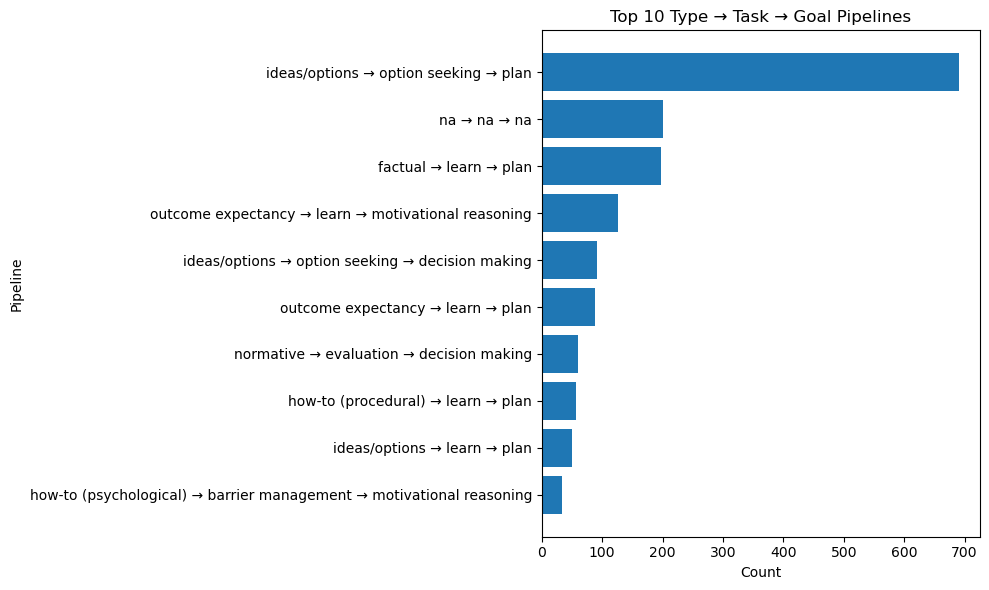

In [80]:
top_pipelines = pipeline_counts.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top_pipelines['pipeline'], top_pipelines['count'])
plt.title('Top 10 Type → Task → Goal Pipelines')
plt.xlabel('Count')
plt.ylabel('Pipeline')
plt.tight_layout()
plt.show()

## 8. Most common pairwise combinations

Besides the full pipeline, it is also useful to identify the most common two-way combinations.

Why this matters:
- Two-way combinations are often easier to discuss in results sections.
- They help reveal the strongest relationships without requiring the full complexity of three labels.

In [81]:
rel_df['type_task_pair'] = rel_df['final_type'].astype(str) + ' | ' + rel_df['final_task'].astype(str)
rel_df['task_goal_pair'] = rel_df['final_task'].astype(str) + ' | ' + rel_df['final_goal'].astype(str)
rel_df['type_goal_pair'] = rel_df['final_type'].astype(str) + ' | ' + rel_df['final_goal'].astype(str)

print('Top Type | Task pairs')
display(rel_df['type_task_pair'].value_counts().head(10).to_frame('count'))

print('Top Task | Goal pairs')
display(rel_df['task_goal_pair'].value_counts().head(10).to_frame('count'))

print('Top Type | Goal pairs')
display(rel_df['type_goal_pair'].value_counts().head(10).to_frame('count'))

Top Type | Task pairs


,count
type_task_pair,
ideas/options | option seeking,798
outcome expectancy | learn,244
factual | learn,223
na | na,211
normative | evaluation,75
how-to (procedural) | learn,72
ideas/options | learn,63
how-to (psychological) | barrier management,43
experiential | learn,43


Top Task | Goal pairs


,count
task_goal_pair,
option seeking | plan,721
learn | plan,457
na | na,203
learn | motivational reasoning,157
evaluation | decision making,92
option seeking | decision making,92
learn | decision making,75
barrier management | motivational reasoning,45
barrier management | plan,42


Top Type | Goal pairs


,count
type_goal_pair,
ideas/options | plan,758
factual | plan,225
na | na,202
outcome expectancy | motivational reasoning,130
ideas/options | decision making,108
how-to (procedural) | plan,101
outcome expectancy | plan,101
normative | decision making,63
utility | action,58


##  Diversity of labels

This section measures how concentrated or varied the labels are.

Why this matters:
- If one category dominates heavily, that affects interpretation.

In [82]:
print('Number of unique final_type labels:', rel_df['final_type'].nunique())
print('Number of unique final_task labels:', rel_df['final_task'].nunique())
print('Number of unique final_goal labels:', rel_df['final_goal'].nunique())
print('Number of unique pipelines:', rel_df['pipeline'].nunique())

Number of unique final_type labels: 11
Number of unique final_task labels: 7
Number of unique final_goal labels: 5
Number of unique pipelines: 82


## Example rows from common pipelines


In [83]:
top_pipeline_names = pipeline_counts['pipeline'].head(3).tolist()

for p in top_pipeline_names:
    print('\n' + '='*80)
    print('Pipeline:', p)
    display(
        rel_df.loc[rel_df['pipeline'] == p, ['participant_no', 'week_no', 'query', 'final_type', 'final_task', 'final_goal']]
        .head(5)
    )


Pipeline: ideas/options → option seeking → plan


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan



Pipeline: na → na → na


,participant_no,week_no,query,final_type,final_task,final_goal
176,102,Week 4,charlotte stingray give birth,na,na,na
203,119,Week 3,lense,na,na,na
204,119,Week 3,https://docs.google.com/document/d/1JvA9x6iJetLrRtkZG0qB1oQ_7QyON3xEYUHsEwTu1UQ/edit?urp=gmail_link,na,na,na
234,119,Week 4,paypal login,na,na,na
250,119,Week 4,https://mx.technolutions.net/ss/c/u001.yAWHLkb7QxrqAOlNdz1qpSDd1V_9_bPbG_LV2M3mES7JCnPdmpVOygwExPEdp7zFrX-8JlCYPorb9...,na,na,na



Pipeline: factual → learn → plan


,participant_no,week_no,query,final_type,final_task,final_goal
60,102,Week 2,what happens when you don't eat enough when working out,factual,learn,plan
61,102,Week 2,what happens your bodywhen you don't eat enough when working out,factual,learn,plan
63,102,Week 2,how many calories do you lose in a day,factual,learn,plan
64,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan
65,102,Week 2,how many calories do you lose in a day normally,factual,learn,plan
